# Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from kerastuner.tuners import RandomSearch
from tensorflow.keras.optimizers import Adam, RMSprop

In [32]:
dataset = pd.read_csv("google_stock.csv", parse_dates=['Date'], index_col='Date')

In [33]:
dataset.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
2004-08-20,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2004-08-23,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
2004-08-24,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
2004-08-25,2.614201,2.689918,2.587302,2.640104,2.640104,184645512


In [34]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4858 entries, 2004-08-19 to 2023-12-05
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       4858 non-null   float64
 1   High       4858 non-null   float64
 2   Low        4858 non-null   float64
 3   Close      4858 non-null   float64
 4   Adj Close  4858 non-null   float64
 5   Volume     4858 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 265.7 KB


In [35]:
dataset.isna().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

# EDA

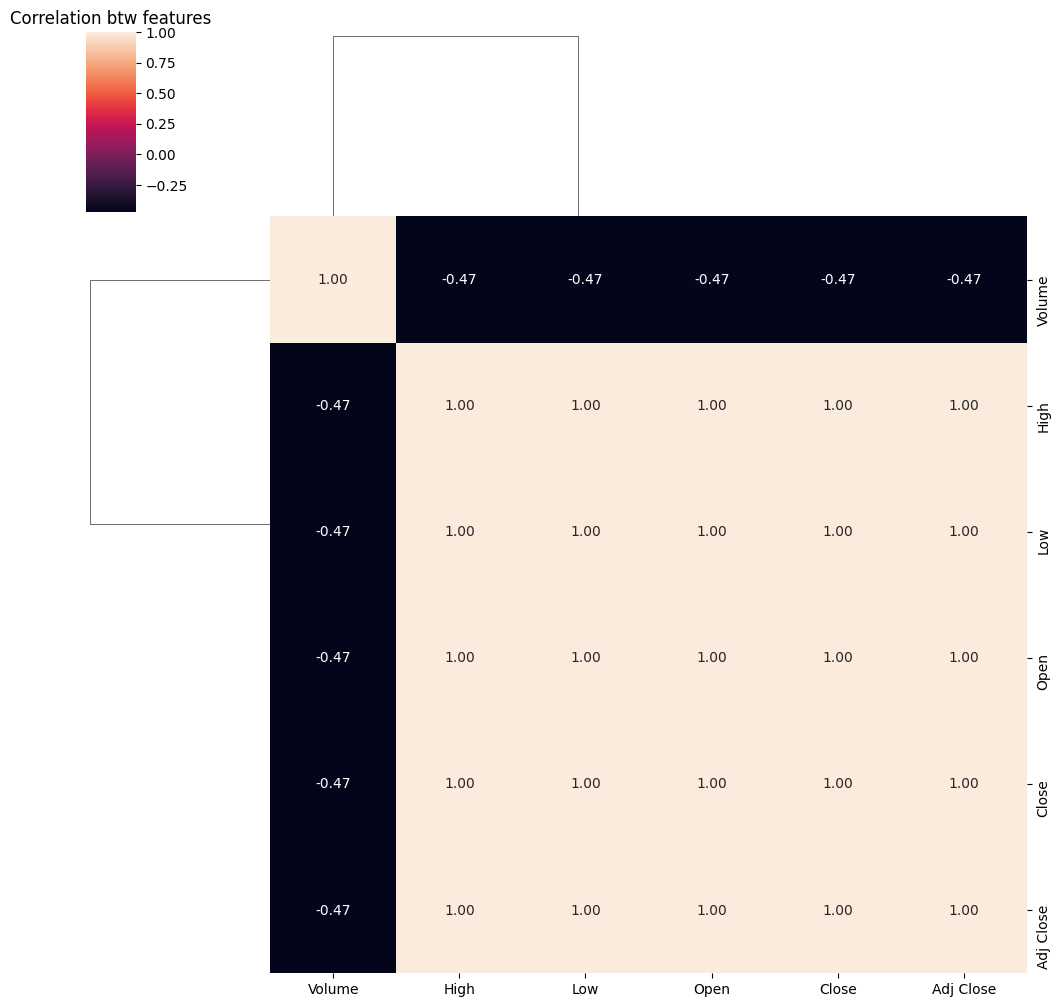

In [36]:
corr_matrix = dataset.corr()
sns.clustermap(corr_matrix,annot = True,fmt = '.2f')
plt.title("Correlation btw features")
plt.show()

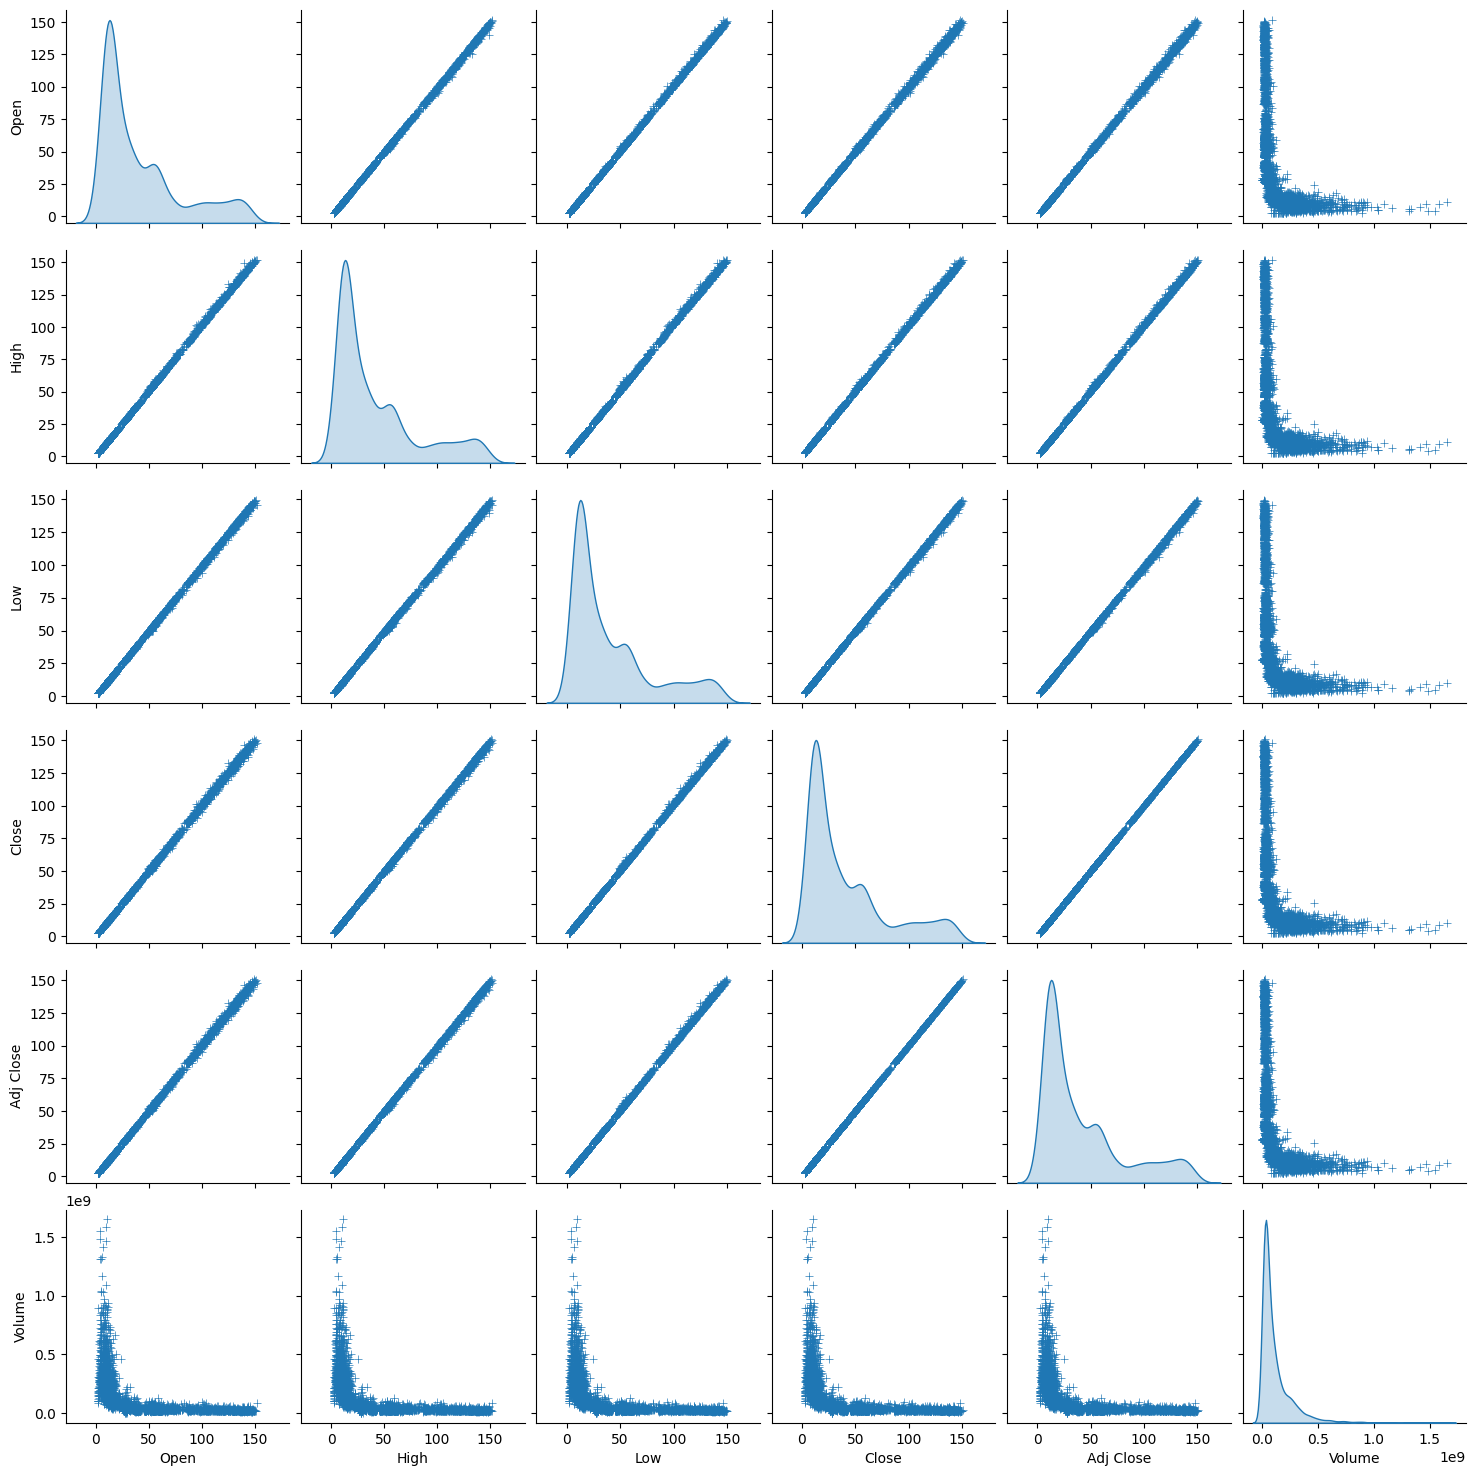

In [37]:
sns.pairplot(dataset,diag_kind="kde",markers = "+")
plt.show()

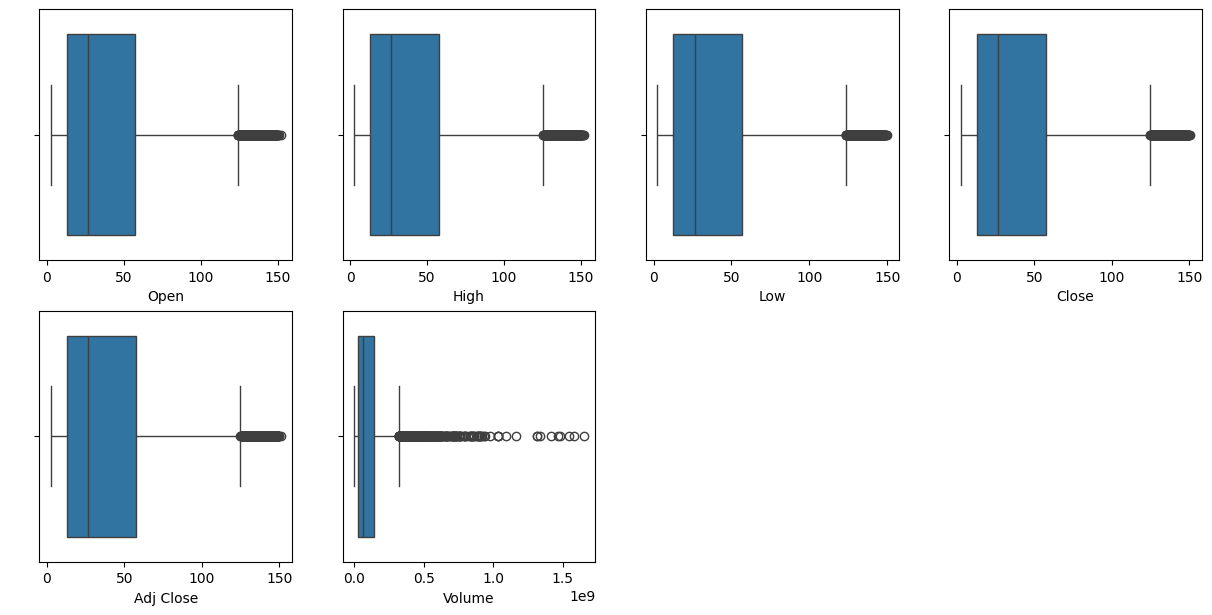

In [38]:
plt.figure(figsize=(15,15))
col = dataset.columns

for i in range(len(col)):
    plt.subplot(4,4,i+1)
    sns.boxplot(x = dataset[col[i]],data=dataset,orient="h")
    plt.xlabel(col[i].replace('_'," "))
    plt.ylabel(' ')

# Prediction

In [39]:
data = dataset[['Open']].values

data

array([[  2.490664],
       [  2.51582 ],
       [  2.758411],
       ...,
       [133.320007],
       [131.294006],
       [130.369995]])

In [40]:
train_size = int(len(data) * 0.9)
train_data = data[:train_size]
test_data = data[train_size - 60:]

testDate = dataset.index[train_size:]

In [41]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [42]:
X_train, y_train = [], []
for i in range(60, len(train_scaled)):
    X_train.append(train_scaled[i-60:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

In [43]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(60, 1)))
model.add(Dropout(0.1))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.1))
model.add(Dense(units=1))

opt = Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss='mean_squared_error')

model.summary()

d:\data_mining\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(X_train, y_train, epochs=250, batch_size=32)

Epoch 1/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 0.0128
Epoch 2/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 5.1480e-04
Epoch 3/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 3.5433e-04
Epoch 4/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 3.6541e-04
Epoch 5/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 3.9503e-04
Epoch 6/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 3.2943e-04
Epoch 7/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 3.5610e-04
Epoch 8/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 3.4752e-04
Epoch 9/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 3.1875e-04
Epoch 10/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 4.0090e-04
Epoch 11/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 3.6267e-04
Epoch 12/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 3.1161e-04
Epoch 13/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 4.2636e-04
Epoch 14/250
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/

[Text(0.5, 0, 'Epochs')]

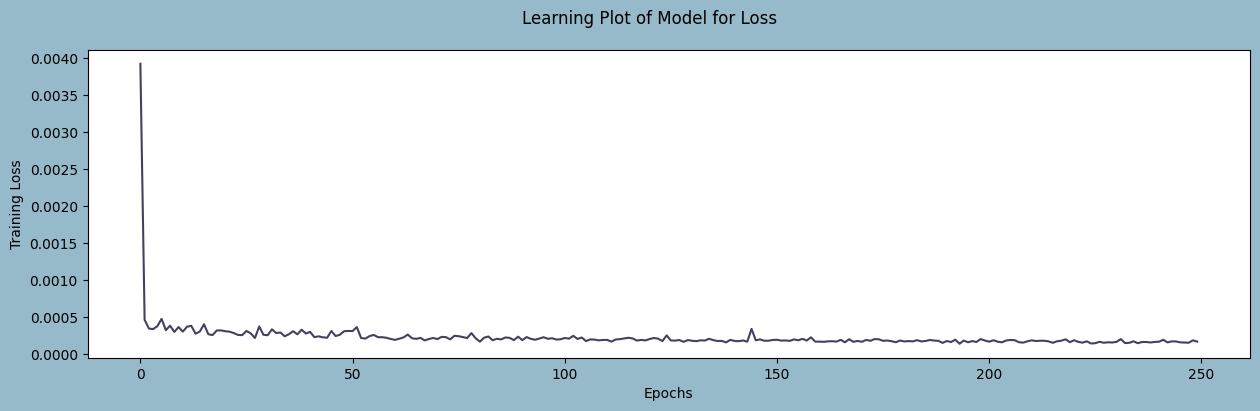

In [45]:
history_df = pd.DataFrame(history.history)
fig = plt.figure(figsize=(15,4), facecolor="#97BACB")
fig.suptitle("Learning Plot of Model for Loss")
pl=sns.lineplot(data=history_df["loss"],color="#444160")
pl.set(ylabel ="Training Loss")
pl.set(xlabel ="Epochs")

In [46]:
loss_values = history.history['loss']
index_of_min_value = loss_values.index(min(loss_values))
print(f"min loss:{min(loss_values)} , epoch size: {index_of_min_value}")

min loss:0.00014243804616853595 , epoch size: 193


In [47]:
X_test = []
for i in range(60, len(test_scaled)):
    X_test.append(test_scaled[i-60:i, 0])
X_test = np.array(X_test)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [48]:
predicted_prices = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices)
actual_prices = data[train_size:]

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


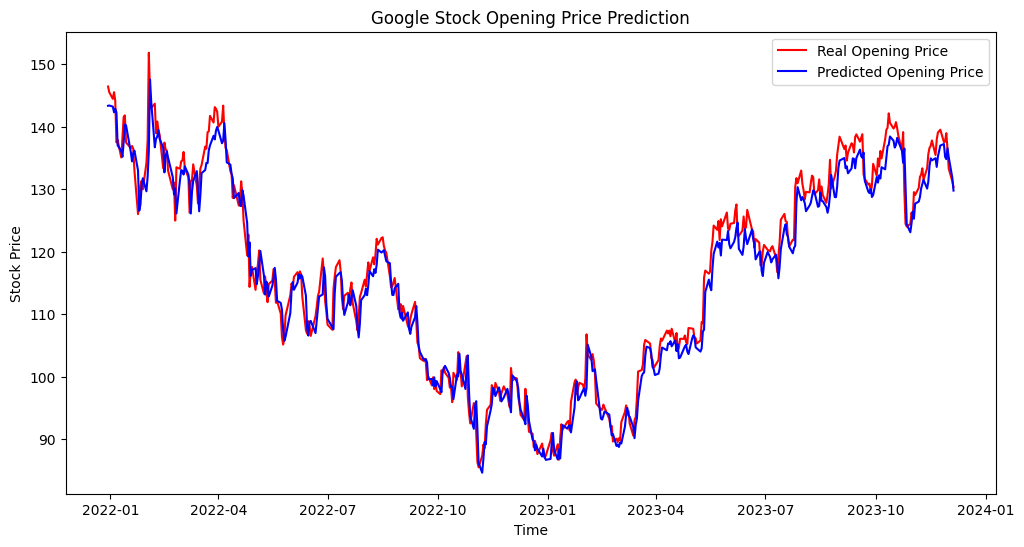

In [49]:
plt.figure(figsize=(12,6))
plt.plot(testDate,actual_prices, color='red', label='Real Opening Price')
plt.plot(testDate,predicted_prices, color='blue', label='Predicted Opening Price')
plt.title('Google Stock Opening Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Mengukur Tingkat Akurasi

In [54]:
y_true = actual_prices
y_pred = predicted_prices

In [55]:
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

In [56]:
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 2.2669
MSE  : 8.1926
RMSE : 2.8623
R²   : 0.9692
